# Notebook 3 — Preprocessing

**Input:** `combined_features.csv` (52 features + Label)

**Output:** `X_train_sc.npy`, `X_test_sc.npy`, `y_train.npy`, `y_test.npy`, `scaler.pkl`, `feature_cols.pkl`

---

## Steps
| Step | Action | Why |
|---|---|---|
| 3A | Train/test split 80/20 stratified | Keep class ratio equal in both splits |
| 3B | StandardScaler fit on X_train only | Never let test data influence scaler |
| 3C | Save scaler + feature columns | Must reuse same scaler for live capture |
| 3D | Save split arrays as .npy | Fast reload for model notebooks |

---

### Why stratified split?
WebAttack has only 2,180 rows (0.08%). Without `stratify=y`, the split might put all WebAttack rows into train and zero into test — model can never be evaluated on rare classes.

### Why scale even for Random Forest / XGBoost?
RF and XGBoost don't strictly need scaling — but **SVM and LightGBM do**. Scaling all 4 models with the same data keeps the comparison fair.

### Golden rule of scaling
> Fit scaler **only** on X_train. Transform X_test and live data using the **same fitted scaler**. Never refit.

In [2]:
import pandas as pd
import numpy as np
import joblib
import os
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

CSV_PATH   = r'D:\Computer Engineering 2022\4-CE.Z Forth Year\second-semester-4.2\project\ML-NIDS-Android\03-dataset\02-processed\combined_features.csv'
OUTPUT_DIR = os.path.dirname(CSV_PATH)

df = pd.read_csv(CSV_PATH)
df.columns = df.columns.str.strip()
print(f'Loaded: {df.shape}')

Loaded: (2827829, 53)


In [3]:
# ── 3A: Split features and labels ────────────────────────────────────────────
FEATURE_COLS = [c for c in df.columns if c != 'Label']
X = df[FEATURE_COLS].values
y = df['Label'].values

print(f'Features : {len(FEATURE_COLS)}')
print(f'Samples  : {len(X):,}')
print(f'Classes  : {np.unique(y)}')

Features : 52
Samples  : 2,827,829
Classes  : [0 1 2 3 4 5 6]


In [4]:
# ── 3B: Train/test split 80/20 stratified ────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'Train size : {len(X_train):,}  ({len(X_train)/len(X)*100:.1f}%)')
print(f'Test size  : {len(X_test):,}  ({len(X_test)/len(X)*100:.1f}%)')

# Verify stratification
LABEL_NAMES = {0:'BENIGN',1:'DoS',2:'DDoS',3:'PortScan',4:'BruteForce',5:'WebAttack',6:'Bot'}
print('\nClass distribution in train vs test:')
print(f'{"Class":<14} {"Train":>10} {"Test":>10} {"Train%":>8} {"Test%":>8}')
for cls in np.unique(y):
    tr = np.sum(y_train == cls)
    te = np.sum(y_test  == cls)
    print(f'{LABEL_NAMES[cls]:<14} {tr:>10,} {te:>10,} {tr/len(y_train)*100:>7.2f}% {te/len(y_test)*100:>7.2f}%')

Train size : 2,262,263  (80.0%)
Test size  : 565,566  (20.0%)

Class distribution in train vs test:
Class               Train       Test   Train%    Test%
BENIGN          1,817,056    454,264   80.32%   80.32%
DoS               201,369     50,343    8.90%    8.90%
DDoS              102,420     25,605    4.53%    4.53%
PortScan          127,043     31,761    5.62%    5.62%
BruteForce         11,066      2,766    0.49%    0.49%
WebAttack           1,744        436    0.08%    0.08%
Bot                 1,565        391    0.07%    0.07%


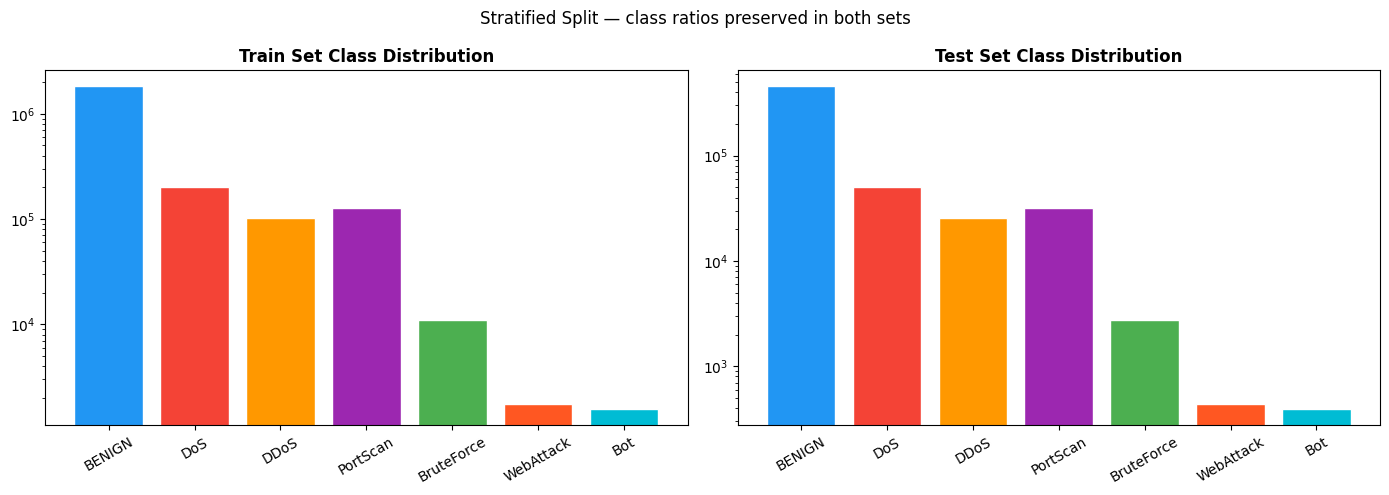

Saved 03_train_test_split.png


In [5]:
# Plot train vs test class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
class_names = [LABEL_NAMES[i] for i in sorted(np.unique(y))]
colors = ['#2196F3','#F44336','#FF9800','#9C27B0','#4CAF50','#FF5722','#00BCD4']

train_counts = [np.sum(y_train==i) for i in sorted(np.unique(y))]
test_counts  = [np.sum(y_test==i)  for i in sorted(np.unique(y))]

axes[0].bar(class_names, train_counts, color=colors, edgecolor='white')
axes[0].set_title('Train Set Class Distribution', fontweight='bold')
axes[0].set_yscale('log')
axes[0].tick_params(axis='x', rotation=30)

axes[1].bar(class_names, test_counts, color=colors, edgecolor='white')
axes[1].set_title('Test Set Class Distribution', fontweight='bold')
axes[1].set_yscale('log')
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('Stratified Split — class ratios preserved in both sets', fontsize=12)
plt.tight_layout()
plt.savefig('03_train_test_split.png', dpi=150)
plt.show()
print('Saved 03_train_test_split.png')

In [6]:
# ── 3C: StandardScaler — fit on train only ────────────────────────────────────
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   # fit + transform
X_test_sc  = scaler.transform(X_test)        # transform only

print('Scaler fitted on X_train only.')
print(f'X_train_sc mean (should be ~0): {X_train_sc.mean():.6f}')
print(f'X_train_sc std  (should be ~1): {X_train_sc.std():.6f}')

Scaler fitted on X_train only.
X_train_sc mean (should be ~0): 0.000000
X_train_sc std  (should be ~1): 1.000000


In [7]:
# ── 3D: Save everything ───────────────────────────────────────────────────────
joblib.dump(scaler,       os.path.join(OUTPUT_DIR, 'scaler.pkl'))
joblib.dump(FEATURE_COLS, os.path.join(OUTPUT_DIR, 'feature_cols.pkl'))

np.save(os.path.join(OUTPUT_DIR, 'X_train_sc.npy'), X_train_sc)
np.save(os.path.join(OUTPUT_DIR, 'X_test_sc.npy'),  X_test_sc)
np.save(os.path.join(OUTPUT_DIR, 'y_train.npy'),    y_train)
np.save(os.path.join(OUTPUT_DIR, 'y_test.npy'),     y_test)

print('Saved files:')
print('  scaler.pkl        — StandardScaler fitted on train')
print('  feature_cols.pkl  — list of 52 feature column names')
print('  X_train_sc.npy    — scaled training features')
print('  X_test_sc.npy     — scaled test features')
print('  y_train.npy       — train labels')
print('  y_test.npy        — test labels')
print(f'\nReady for Notebook 4 (Model Training)')

Saved files:
  scaler.pkl        — StandardScaler fitted on train
  feature_cols.pkl  — list of 52 feature column names
  X_train_sc.npy    — scaled training features
  X_test_sc.npy     — scaled test features
  y_train.npy       — train labels
  y_test.npy        — test labels

Ready for Notebook 4 (Model Training)
